In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487060172094
V1.0.0.7
V10.1

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V4E-901.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1128 non-null   str  
 1   Message  1128 non-null   str  
 2   Status   1128 non-null   str  
dtypes: str(3)
memory usage: 26.6 KB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    915
0x252514    205
0x252501      4
0x252511      4
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1128 non-null   str  
 1   Message  1128 non-null   str  
 2   Status   1128 non-null   str  
 3   Headers  1128 non-null   str  
dtypes: str(4)
memory usage: 35.4 KB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1120 entries, 0 to 1123
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             1120 non-null   str  
 1   Message             1120 non-null   str  
 2   Status              1120 non-null   str  
 3   Headers             1120 non-null   str  
 4   Odometer in meters  1120 non-null   int64
 5   Date                1120 non-null   str  
 6   Raw data            1120 non-null   str  
dtypes: int64(1), str(6)
memory usage: 70.0 KB
None


260925003840 -> 0 -> 90778.0 -> 0x252514005906050869487060172094003C38402D00002952500000000700644100000000000000FFFFFFFFFFFF16D50001629A002609250038409A991245CD2B8FC2FE2283C10000010F03961239FFFFFF00001B0000FFFFFF
260925003941 -> 1 -> 90778.0 -> 0x252513005930FC0869487060172094003C38402D0000294F500000000700644100000000000000FFFFFFFFFFFF00D50001629A002609250039419A991245CD2B8FC2FE2283C10000010F03971300FFFFFF00001B0000FFFFFF
260925004041 -> 2 -> 90778.0 -> 0x252513005930FD0869487060172094003C38402D0000294B500000000700644100000000000000FFFFFFFFFFFF00D50001629A002609250040419A991245CD2B8FC2FE2283C10000010F03971287FFFFFF00001B0000FFFFFF
260925004140 -> 3 -> 90778.0 -> 0x252513005930FE0869487060172094003C38402D00002952500000000700644100000000000000FFFFFFFFFFFF00D50001629A002609250041409A991245CD2B8FC2FE2283C10000010F03971284FFFFFF00001B0000FFFFFF
260925004241 -> 4 -> 90778.0 -> 0x252513005930FF0869487060172094003C38402D00002952500000000700644100000000000000FFFFFFFFFFFF00D50001629A002609250042

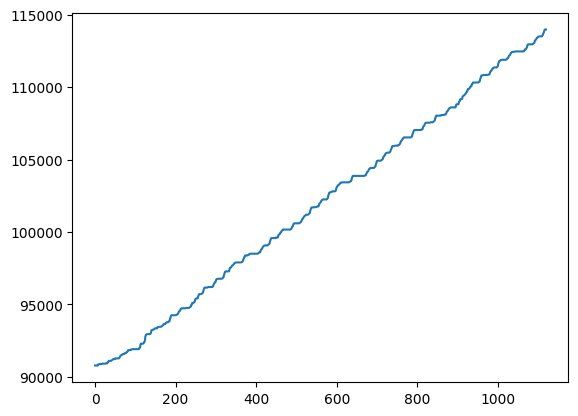

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [7]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


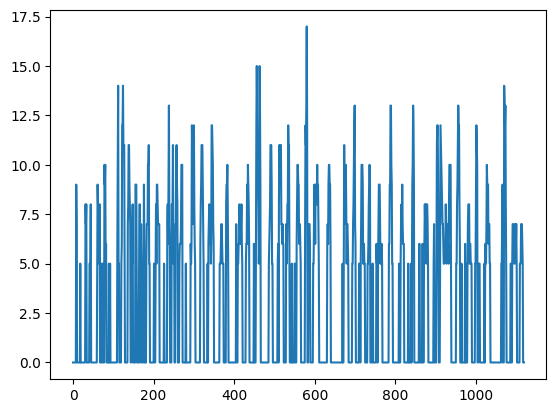

In [8]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 128, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Satellites Number

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 1120 entries, 0 to 1123
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         1120 non-null   str  
 1   Message                         1120 non-null   str  
 2   Status                          1120 non-null   str  
 3   Headers                         1120 non-null   str  
 4   Satellites                      1120 non-null   int64
 5   Satellite_connection_indicator  1120 non-null   int64
 6   Raw data                        1120 non-null   str  
 7   date                            1120 non-null   str  
dtypes: int64(2), str(6)
memory usage: 78.8 KB
Eventos históricos:  0


Coordinates

In [11]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 1120 entries, 0 to 1123
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            1120 non-null   str    
 1   Message            1120 non-null   str    
 2   Status             1120 non-null   str    
 3   Headers            1120 non-null   str    
 4   Latitude           1120 non-null   str    
 5   Latitude_decoded   1120 non-null   float64
 6   Longitude          1120 non-null   str    
 7   Longitude_decoded  1120 non-null   float64
 8   Raw data           1120 non-null   str    
 9   Date               1120 non-null   str    
 10  Speed              1120 non-null   int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 105.0 KB
None
260925003840 -> FE2283C1 -> -16.392086029052734 -> CD2B8FC2 -> -71.5855484008789 0x252514005906050869487060172094003C38402D00002952500000000700644100000000000000FFFFFFFFFFFF16D50001629A002609250038409A991245CD2B8FC2FE228

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [12]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V4E-901.csv')

<class 'pandas.DataFrame'>
Index: 1120 entries, 1 to 1123
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1120 non-null   str  
 1   Message  1120 non-null   str  
 2   Status   1120 non-null   str  
 3   Headers  1120 non-null   str  
dtypes: str(4)
memory usage: 43.8 KB


Ignition

In [13]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 1119 entries, 914 to 1118
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  1119 non-null   str  
 1   date         1119 non-null   str  
 2   raw data     1119 non-null   str  
dtypes: str(3)
memory usage: 35.0 KB
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition Off 0b0
Ignition Off 0b0
Ignition Off 0b0
Ignition On 0b100000

Door detection

In [14]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [15]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V4E-901.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   1119 non-null   int64
 1   in and outs  1119 non-null   str  
 2   date         1119 non-null   int64
 3   raw data     1119 non-null   str  
dtypes: int64(2), str(2)
memory usage: 35.1 KB


Panic detection

In [16]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  1119 non-null   str  
 1   date         1119 non-null   str  
 2   raw data     1119 non-null   str  
dtypes: str(3)
memory usage: 26.4 KB


In [17]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

iButton

In [18]:
id_button_m=raw_data[raw_data['Headers'].str.contains('0x252523')]
device_id=[]
id_button_date=[]

for i in range(0,id_button_m.shape[0]):
    device_id.append(id_button_m.iloc[i,2][84:100])
    id_button_date.append(id_button_m.iloc[i,2][32:44])
    print(id_button_m.iloc[i,2][84:100],id_button_m.iloc[i,2][32:44])

id_button_m['date']=id_button_date
id_button_m['device_id']=device_id

yymmdd=[]

for i in range(0,id_button_m.shape[0]):
    yymmdd.append(id_button_m.iloc[i,2][32:38])

id_button_m['yymmdd']=yymmdd
id_button_m.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Created    0 non-null      str    
 1   Message    0 non-null      str    
 2   Status     0 non-null      str    
 3   Headers    0 non-null      str    
 4   date       0 non-null      float64
 5   device_id  0 non-null      float64
 6   yymmdd     0 non-null      float64
dtypes: float64(3), str(4)
memory usage: 132.0 bytes


In [19]:
id_button_m['yymmdd'].value_counts()

Series([], Name: count, dtype: int64)

log de conductores

In [20]:
log=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\hl_v4e901.xlsx')
sn='V4E-901'
log_v4e_901=log[log['Unidad'].str.contains('V4E-901')]
log_v4e_901

,Secuencia,Unidad,Eventos,Fecha,Pt. Referencia,Dirección,Velocidad,Temperatura,Conductor,Latitud,Longitud
0,1107,V4E-901,Ignición Apagada,Oct 02 2026 08:57 AM,NaN,"Av Pe-34 A-81, Cerro Colorado, Arequipa, Arequ...",0,NaN,NaN,-16.392464,-71.583488
1,1106,V4E-901,Inmóvil - Detenido,Oct 02 2026 08:56 AM,NaN,"Av Pe-34 A-81, Cerro Colorado, Arequipa, Arequ...",0,NaN,NaN,-16.392464,-71.583488
2,1105,V4E-901,Inmóvil - Detenido,Oct 02 2026 08:55 AM,NaN,"Av Pe-34 A-81, Cerro Colorado, Arequipa, Arequ...",0,NaN,NaN,-16.392464,-71.583488
3,1104,V4E-901,Conduciendo,Oct 02 2026 08:53 AM,NaN,"Av Pe-34 A-76, Cerro Colorado, Arequipa, Arequ...",4,NaN,NaN,-16.392458,-71.583572
4,1103,V4E-901,Conduciendo,Oct 02 2026 08:53 AM,NaN,"Av Pe-34 A-51, Cerro Colorado, Arequipa, Arequipa",6,NaN,NaN,-16.393011,-71.583771
...,...,...,...,...,...,...,...,...,...,...,...
1102,5,V4E-901,Ignición Apagada,Sep 25 2026 03:08 AM,NaN,"Via de Evitamiento 123, Arequipa, Peru",0,NaN,NaN,-16.392099,-71.585678
1103,4,V4E-901,Inmóvil - Detenido,Sep 25 2026 03:07 AM,NaN,"Via de Evitamiento 123, Arequipa, Peru",0,NaN,NaN,-16.392054,-71.585533
1104,3,V4E-901,Inmóvil - Detenido,Sep 25 2026 03:06 AM,NaN,"Via de Evitamiento 123, Arequipa, Peru",0,NaN,NaN,-16.392054,-71.585533
1105,2,V4E-901,Inmóvil - Detenido,Sep 25 2026 03:05 AM,NaN,"Via de Evitamiento 123, Arequipa, Peru",0,NaN,NaN,-16.392054,-71.585533


In [21]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\hl_v4e901.xlsx')
hl['Eventos'].value_counts()

Eventos
Conduciendo              484
Inmóvil - Detenido       386
Ignición Apagada          58
Ignición Encendida        58
Alerta de Inmovilidad     54
Fin de Inmovilidad        29
Estacionado               27
Entrada a Geocerca         6
Salida de Geocerca         5
Name: count, dtype: int64